In [116]:
# Enable autoreload of imported modules

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [117]:
# Compute normalized columns

def normalize_data_columns(df):
    columns = ["n_docs", "dist_smooth_to_prev_smooth", "dispersion", "curvature", "drift_from_baseline"]

    for col in columns:
        df[f"{col}_norm"] = df[col]/df[col].sum()
    
    return df

def normalize_data_columns_per_dataset(df):
    """
    Normalize data per dataset and per group.
    That is, makes column `c` (e.g.: n_docs) in dataset `d` (e.g.: helene) and group `g` (e.g.: event, background) sum to 1.
    """
    columns = ["n_docs", "dist_smooth_to_prev_smooth", "dispersion", "curvature", "drift_from_baseline"]

    cols_norm = [f"{col}_norm" for col in columns]

    df[cols_norm] = df.groupby(["event_name", "group"])[columns].transform(
        lambda x: x/x.sum()
    )
    return df





In [118]:
import pandas as pd
from pathlib import Path


output_dir = Path("results/")
output_dir.mkdir(exist_ok=True)

datasets = [d.name for d in Path("output/").iterdir() if d.is_dir()]

data = []  # Store dataset results from temporal analysis
xlim = (-7,30)  # Define plot limits


# Load event labels
with open("data/event_labels.csv") as fin:
    event_labels = {}
    for line in fin:
        event, label = line.strip().split(",",1)
        event_labels[event] = label

for dataset in datasets:
    data_dir = Path(f"output/{dataset}")

    # Load daily files
    event_df = pd.read_csv(data_dir.joinpath("daily_event.csv"))
    bg_df = pd.read_csv(data_dir.joinpath("daily_background.csv"))
    overall_df = pd.read_csv(data_dir.joinpath("daily_overall.csv"))
    dfs = [overall_df, bg_df, event_df]  # Get all dfs
    
    event_df["group"] = "event"
    bg_df["group"] = "background"
    overall_df["group"] = "overall"
    event_df["event_type"] = event_labels[dataset]
    bg_df["event_type"] = event_labels[dataset]

    ds_df = pd.concat((overall_df, bg_df, event_df))
    ds_df["event_name"] = dataset
    ds_df["event_type"] = event_labels[dataset]
    data.append(ds_df)

df = pd.concat(data).reset_index(drop=True)
df = normalize_data_columns_per_dataset(df)

df.to_csv(output_dir.joinpath("temporal_results_all.csv"), index=None)


In [119]:
import matplotlib.pyplot as plt

def plot_onset_line(ymin=-1, ymax=1, linestyles="-", colors="black", linewidth=1, label="Event onset", ax=None):
    if ax is None:
        plt.autoscale(False)  # Set autoscale before drawing vertical line
        plt.vlines((0), ymin=ymin, ymax=ymax, linestyles=linestyles, colors=colors, linewidths=linewidth, label=label)
    else:
        ax.axvline(x=0, linestyle=linestyles, color=colors, linewidth=linewidth, label=label)

In [120]:
cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm',
        'drift_from_baseline', 'n_topics_active', 'weighted_mean_sim', 'weighted_mean_var',
        ]

In [121]:
### Compute temporal dynamics parameters: peak lag, amplitude, half-life
import numpy as np
from scipy.stats import sem
from analysis.changepoint import preprocess_signal, percentile_bursts


def get_changepoints(x, preprocess_input=True, q=95, window=3, k=1):
        if preprocess_input:
            x_signal = preprocess_signal(x)
        else:
            x_signal = x
            
        cp, rscore, loc, thr = percentile_bursts(x_signal, 
                                            q=q, 
                                            window=window,
                                            location="mad",
                                            k=k,
                                            min_gap=3)

        return {
            "cp": cp,
            "thr": thr,
            "response_scores": rscore.tolist()}

def get_temporal_parameters(df,
                            cols=None,
                            drop_event_types={'political'},
                            error="sem"):
    if cols is None:
        cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm',
                'drift_from_baseline', 'n_topics_active', 'weighted_mean_sim', 'weighted_mean_var',
                'similarity_policy_keywords', 'similarity_misinformation_keywords', 'similarity_hatespeech_keywords']
        
    event_types = sorted(df['event_type'].unique())
    window=5
    rows = list()
    for y_col in cols:
            for evt_t in event_types:
                if evt_t in drop_event_types:
                    continue
                df_t = df[(df['event_type']==evt_t)&(df['group']!='overall')]
                df_t = df_t.sort_values('dt')
                avg_dt = df_t.groupby(['group', 'dt'])[y_col].mean()
                std_dt = df_t.groupby(['group', 'dt'])[y_col].std()

                # Get values for each group
                y_bg = avg_dt.background.rolling(window=window, min_periods=1).mean()
                y_event = avg_dt.event.rolling(window=window, min_periods=1).mean()
                y_event = y_event[y_event.index >= 0]
                
                # Get baseline from background
                y_baseline = avg_dt.background.mean()
            
                # Find peak index and amplitude
                peak_idx = y_event.idxmax()
                amplitude = float(y_event[peak_idx]-y_baseline)

                # Compute half-life
                hl_target = y_baseline + amplitude / 2.0
                tail = y_event[y_event.index > peak_idx]
                cross_mask = tail <= hl_target
                if cross_mask.any():
                    hl_dt = tail.index[np.argmax(cross_mask.values)]
                
    
                x_cp = y_event[(y_event.index >= 0) & (y_event.index <= 30)]
                event_cp = get_changepoints(x_cp, preprocess_input=True, 
                                            q=95, window=5, k=2)
                
                rows.append({
                     "signal": y_col,
                     "event_type": evt_t,
                     "baseline": y_baseline,
                     "peak_idx": peak_idx,
                     "peak_val": y_event[peak_idx],
                     "amplitude": amplitude,
                     "half_life_days": hl_dt,
                     "changepoints": event_cp['cp']
                })
        
    return pd.DataFrame(rows)


results_temp = get_temporal_parameters(df, cols=cols)
results_temp.to_csv(output_dir.joinpath("temporal_parameters.csv"), index=None)

{'cp': [4], 'thr': np.float64(1.1778510362712316), 'response_scores': [0.0, 0.13397490787310315, 0.49091697807511014, 0.9782689719330364, 1.4921775935605572, 1.3641412595953861, 0.9915608129470769, 0.556595456306465, 0.012655507013636788, 0.2732992640296745, 0.5909929111649925, 0.6857181831715565, 0.7240496770960285, 0.6058595072329718, 0.38002675663352015, 0.13612779975262293, 0.0, 0.009744344755089616, 0.020084616942865164, 0.14173699458718986, 0.3333333333333333, 0.41690757040445414, 0.40684987126813515, 0.37028268711877976, 0.33410905407712865, 0.31389608747933884, 0.3019854989956604, 0.2730192135768167, 0.21898188127923043, 0.1858366000047076, 0.1824006593131104]}
{'cp': [4], 'thr': np.float64(1.1800820772532925), 'response_scores': [0.0, 0.1499489639375815, 0.5633127407912737, 1.0034788385491582, 1.4438040991273104, 1.3566853159574268, 0.949873725632553, 0.32883598074678716, 0.0, 0.23317266608852857, 0.5056799526368299, 0.5324527069726575, 0.45680638362173753, 0.35771962567974935

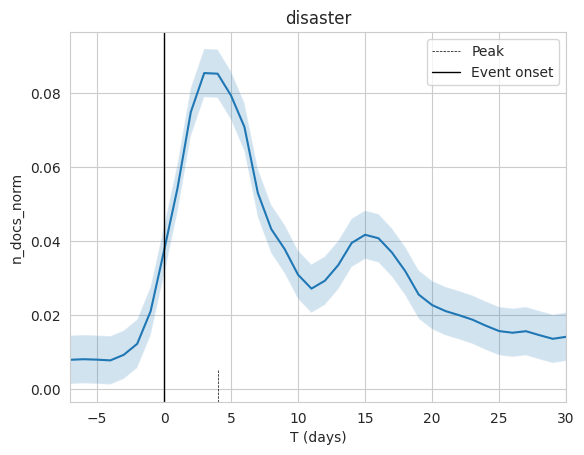

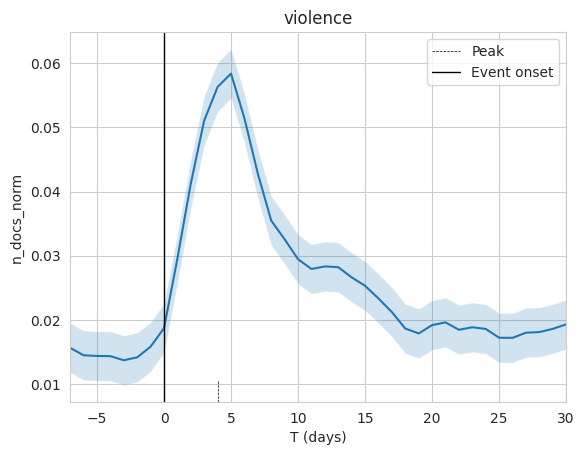

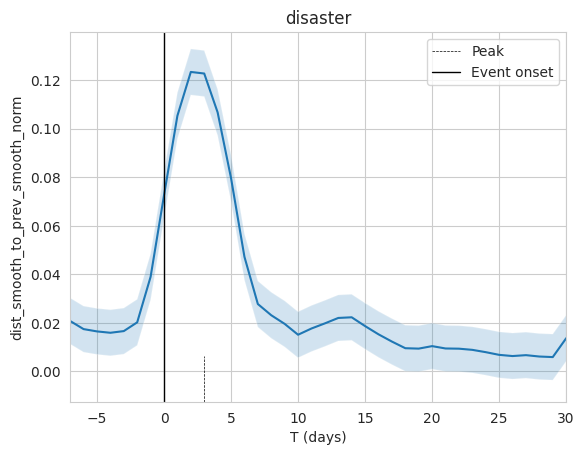

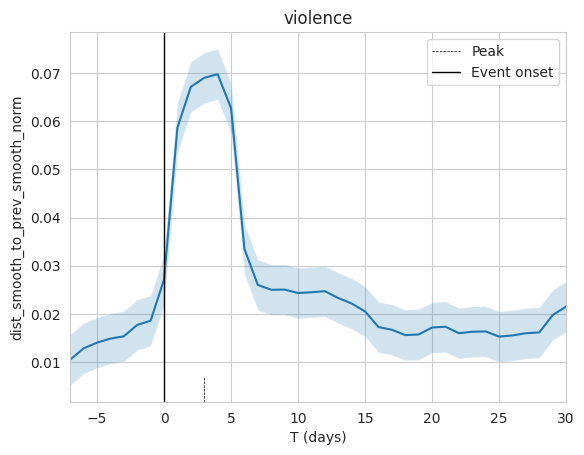

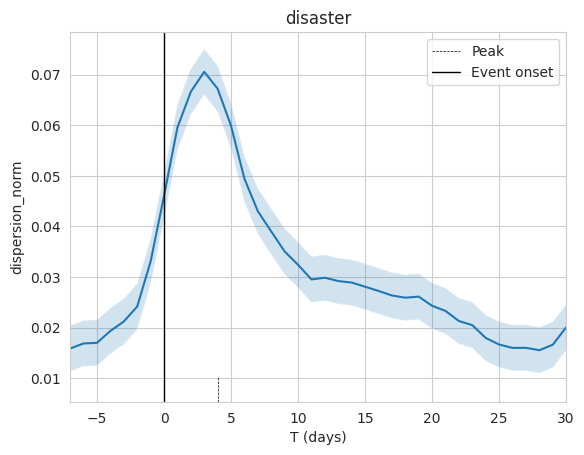

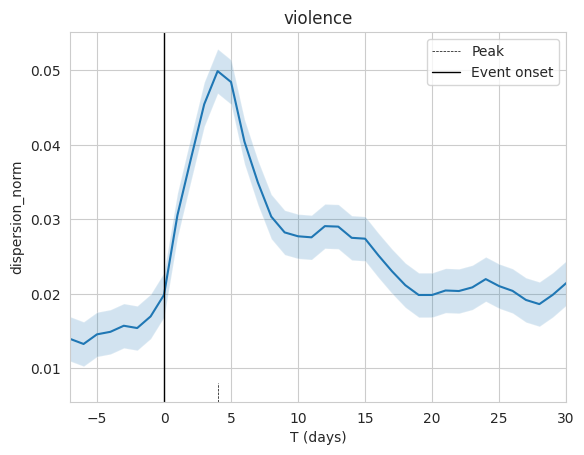

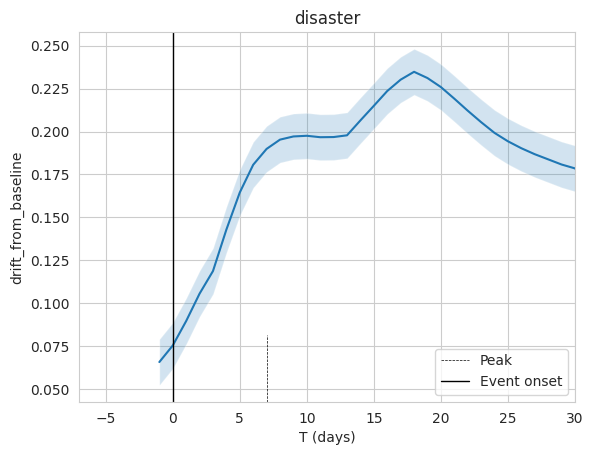

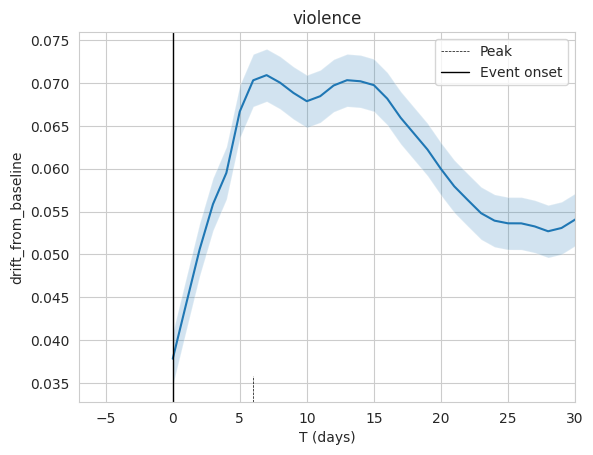

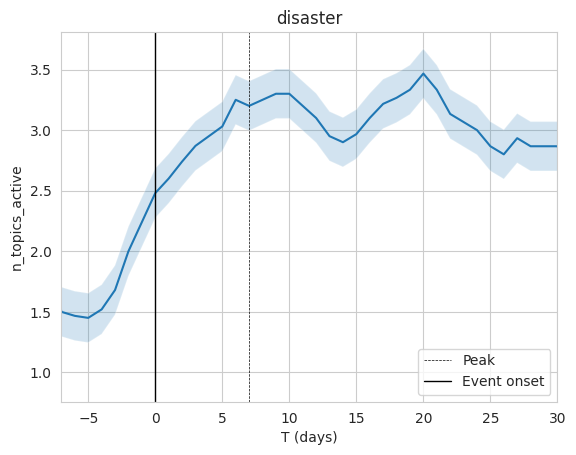

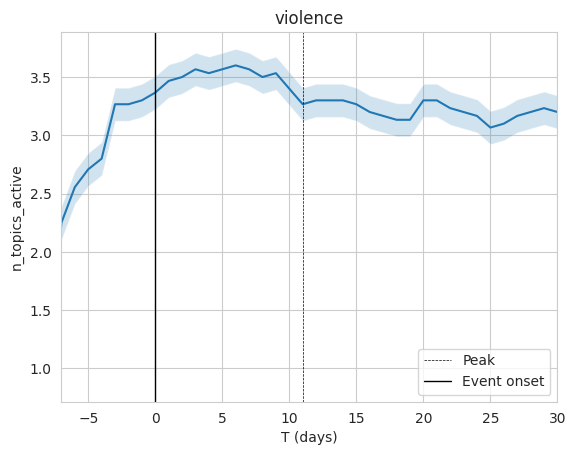

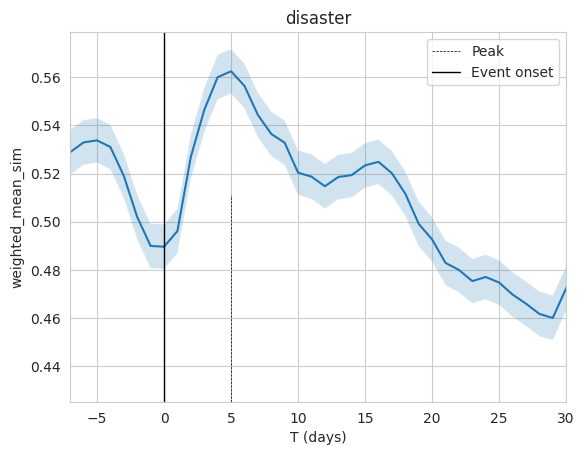

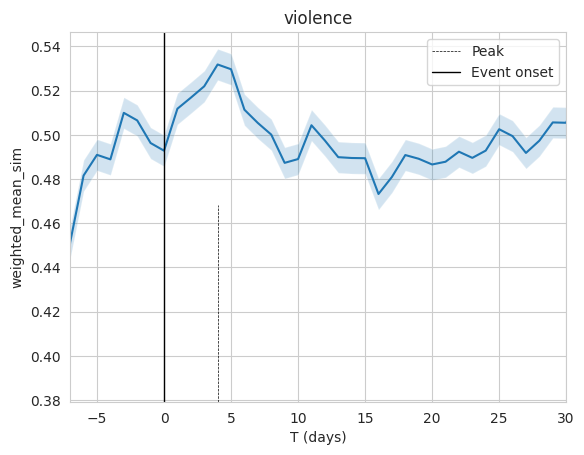

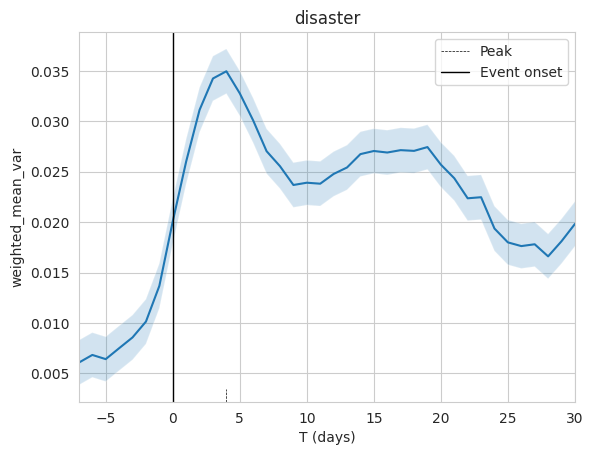

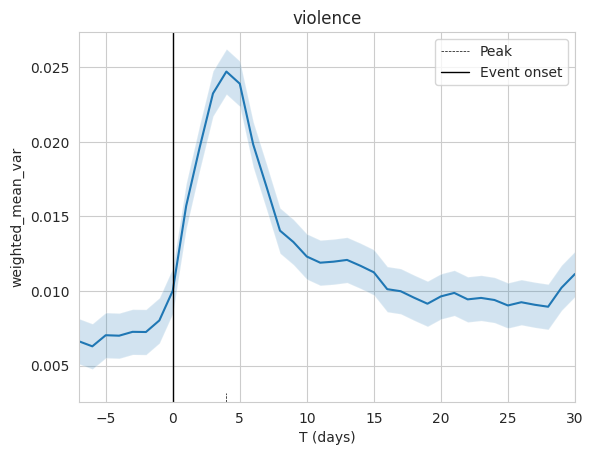

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from analysis.changepoint import percentile_bursts, preprocess_signal

sns.set_style("whitegrid")
from scipy.stats import sem
import numpy as np



def get_changepoints(x, preprocess_input=True, q=95, window=3, k=3):
        if preprocess_input:
            x_signal = preprocess_signal(x)
        else:
            x_signal = x
            
        cp, rscore, loc, thr = percentile_bursts(x_signal, 
                                            q=q, 
                                            window=window,
                                            location="mad",
                                            k=k,
                                            min_gap=3)

        return {
            "cp": cp,
            "thr": thr,
            "response_scores": rscore.tolist()}


def plot_event_background_timeseries(df, 
                                     cols=None,
                                     plot_error=True,
                                     plot_bg=False,
                                     plot_changepoints=True,
                                     drop_event_types={'political'},
                                     error="sem"):

    event_types = sorted(df['event_type'].unique())
    window=5
    x = np.array(sorted(df['dt'].unique()))

    if cols is None:
        cols = ['n_docs_norm', 'dist_smooth_to_prev_smooth_norm', 'dispersion_norm',
                'drift_from_baseline', 'n_topics_active', 'weighted_mean_sim', 'weighted_mean_var',
                ]

    for y_col in cols:
        for evt_t in event_types:
            if evt_t in drop_event_types:
                continue
            df_t = df[(df['event_type']==evt_t)&(df['group']!='overall')]
            df_t = df_t.sort_values('dt')
            avg_dt = df_t.groupby(['group', 'dt'])[y_col].mean()
            std_dt = df_t.groupby(['group', 'dt'])[y_col].std()

            # Get values for each group
            y_bg = avg_dt.background.rolling(window=window, min_periods=1).mean()
            y_event = avg_dt.event.rolling(window=window, min_periods=1).mean()
            
            if plot_changepoints:
                x_cp = y_event[(y_event.index >= 0) & (y_event.index <= 30)]
                event_cp = get_changepoints(x_cp, preprocess_input=True, 
                                            q=95, window=5, k=3)
                print(event_cp)

            if error == "std":
                bg_err = std_dt.background.rolling(window=window, min_periods=1).mean()
                event_err = std_dt.event.rolling(window=window, min_periods=1).mean()
            elif error == "sem":
                bg_err = 2*sem(y_bg, nan_policy="omit")  # Use standard error of mean
                event_err = 2*sem(y_event, nan_policy="omit")

            fig, ax = plt.subplots();
            ax.set_xlim(*xlim)

            if plot_error:
                if plot_bg:
                    ax.fill_between(x[:len(y_bg)], y_bg-bg_err, y_bg+bg_err, alpha=0.2)
                ax.fill_between(x[:len(y_event)], y_event-event_err, y_event+event_err, alpha=0.2)

            if plot_bg:
                ax.plot(x[:len(y_bg)], y_bg);
            ax.plot(x[:len(y_event)], y_event)

            if plot_changepoints:
                for cp in event_cp['cp']:
                    ax.axvline(cp, color="black", linestyle='--', linewidth=0.5, label="Peak")
            
            ax.axvline(0, color='black', linewidth=1, label="Event onset")

            ax.set_title(evt_t);
            ax.legend();
            ax.set_xlabel("T (days)")
            ax.set_ylabel(y_col)
            fig.savefig(output_dir.joinpath(f"{y_col}_{evt_t}.pdf"));

plot_event_background_timeseries(df, cols=cols)